## 1. Configuration

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("../.env")


True

In [2]:
import ee

ee.Authenticate()
ee.Initialize(project=os.getenv("EE_PROJECT_NAME"), opt_url="https://earthengine-highvolume.googleapis.com")


In [3]:
import json

BUCKET_NAME = os.getenv("BUCKET_NAME", "naip_tiles_256")
region_bbox = json.loads(os.getenv("REGION_BBOX", "[-74.2591, 40.4774, -73.7004, 40.9176]"))
region = ee.Geometry.Rectangle(region_bbox)


## 2. Download NAIP Tiles from Earth Engine

In [4]:
image = (
    ee.ImageCollection("USDA/NAIP/DOQQ")
    .filterBounds(region)
    .filterDate("2021", "2022")
    .mosaic()
    .clip(region)
    # .select("N", "R", "G")
)


In [ ]:
import geemap

Map = geemap.Map()
Map.addLayer(image, {}, "Image")
Map.addLayer(region, {}, "ROI", False)
Map.centerObject(region, 10)
Map

In [6]:
# tiles = region.coveringGrid("EPSG:3857", 2560)
tiles = region.coveringGrid("EPSG:3857", 256)


In [7]:
Map.addLayer(tiles, {}, "grids", False)
Map

Map(bottom=98576.0, center=[40.697299008636755, -73.97918701171876], controls=(WidgetControl(options=['positio…

In [8]:
from google.cloud import storage

# initialize a single client
_storage_client = storage.Client()

def _gz_blob_exists(gs_uri: str) -> bool:
    """
    Check whether a gs://bucket/path/to/blob exists.
    """
    # strip off “gs://” then split
    bucket_name, blob_path = gs_uri[5:].split("/", 1)
    bucket = _storage_client.bucket(bucket_name)
    return bucket.get_blob(blob_path) is not None


In [9]:
# Export each tile to GCS
def exportTile(f):
    geom = f.geometry()
    name = f.id().getInfo() or geom.centroid().getInfo()["coordinates"]
    export_path = f"gs://{BUCKET_NAME}/{name}.tif"

    if _gz_blob_exists(export_path):
        print(f"Skipping {name}, already exists.")
        return

    task = ee.batch.Export.image.toCloudStorage(
        image=image.clip(geom),
        description=f"NAIP_NYC_{name}",
        bucket=BUCKET_NAME,
        fileNamePrefix=f"{name}",
        region=geom,
        scale=1,
        crs="EPSG:3857",
        maxPixels=1e10
    )
    # task.start()
    return task


In [10]:
tiles.size().getInfo()

61722

In [11]:
tiles_with_count = tiles.map(lambda f: f.set({
    "count": image
        .select("R")                                  # pick one band
        .reduceRegion(
            reducer=ee.Reducer.count(),               # count of non-masked pixels
            geometry=f.geometry(),
            scale=1,                                  # 1 m native resolution
            maxPixels=1e8
        ).get("R")                                    # get the “R” count
}))


In [12]:
valid_tiles = tiles_with_count.filter(ee.Filter.gt("count", 0))

In [15]:
valid_tiles.size().getInfo()

42650

In [13]:
Map.addLayer(valid_tiles, {}, "valid_tiles", False)
Map

Map(bottom=98876.0, center=[40.697299008636755, -73.97918701171876], controls=(WidgetControl(options=['positio…

In [14]:
file_task_coll = {}


In [ ]:
from time import time

total_size = valid_tiles.size().getInfo()  # 42650
print(f"Total grids: {total_size}")

N = 3000

# for offset in range(N*14, total_size, N):
for offset in range(0, total_size, N):
    print(f"\nProcessing grids {offset}–{min(offset + N, total_size)}")

    # Fetch this batch as a Python list
    fc_dict = valid_tiles.toList(N, offset).getInfo()
    print(f"Fetched {len(fc_dict)} grids.")

    # Iterate over the raw feature dicts
    for feat_dict in fc_dict:
        feat = ee.Feature(feat_dict)   # re-wrap as an ee.Feature
        task = exportTile(feat)
        if task is not None:
            if feat.id().getInfo() not in list(file_task_coll.keys()):
                # file_task_coll[.id().getInfo() or geom.centroid().getInfo()["coordinates"]]
                # print(dir(task))
                task.start()
                file_task_coll[feat.id().getInfo()] = task.id
                print(f"added task {task.id} for {feat.id().getInfo()}")
                # print(f"Task name: {task.name}")
            else:
                print(f"Task {file_task_coll[feat.id().getInfo()] } for {feat.id().getInfo()} already exists.")
                # print(f"Task {task.id} for {feat.id().getInfo()} already exists.")
    print("====================================================================")
    print("====================================================================")
    print("====================================================================")
    print(f"\Processed grid offset {offset}")
    print("====================================================================")
    print("====================================================================")
    print("====================================================================")
    # break

    # time.sleep(1.2 * 60 * 60) # sleep for 1.2 hours to avoid rate limits


## 3. Compute SkyCLIP Embeddings

In [15]:
import os
import sys
sys.path.append("../")

import io
import pyproj
import pandas as pd
from rasterio.io import MemoryFile

from google.cloud import storage
from PIL import Image
import torch
from src.open_clip.factory import create_model_and_transforms, get_tokenizer
from src.training.precision import get_autocast


In [16]:
# Init GCS client & list
client = storage.Client()
bucket = client.bucket(BUCKET_NAME)
blobs = list(bucket.list_blobs())
tile_paths = [b.name for b in blobs if b.name.endswith(".tif")]


In [17]:
len(tile_paths)


42650

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cpu


In [19]:
model_arch_name = "ViT-L-14" # or 'ViT-B-32'
ckpt_name = os.path.join("..", os.getenv("CKPT_PATH", "data/checkpoints/SkyCLIP_ViT_L14_top30pct_filtered_by_CLIP_laion_RS/epoch_20.pt"))


In [20]:
precision="amp"
batch_size = 128
autocast = get_autocast(precision)


In [21]:
model, _, preprocess_val = create_model_and_transforms(
    model_arch_name,
    ckpt_name,
    precision=precision,
    device=device,
    output_dict=True,
    force_quick_gelu=True,
    # weights_only=True,
)

tokenizer = get_tokenizer(model_arch_name)


In [22]:
def create_geometry_wkt(west, south, east, north):
    """
    Create WKT POLYGON from bounding box coordinates.

    Args:
        west, south, east, north: Bounding box coordinates

    Returns:
        WKT string for the polygon
    """
    # Create a polygon from the bounding box (clockwise order)
    polygon_wkt = f"POLYGON(({west} {south}, {east} {south}, {east} {north}, {west} {north}, {west} {south}))"
    return polygon_wkt


def transform_bounds_to_wgs84(west, south, east, north, source_crs="EPSG:3857"):
    """
    Transform bounding box from source CRS to WGS84 (EPSG:4326) for BigQuery GEOGRAPHY.

    Args:
        west, south, east, north: Bounding box coordinates in source CRS
        source_crs: Source coordinate reference system (default: Web Mercator)

    Returns:
        (west_wgs84, south_wgs84, east_wgs84, north_wgs84) in WGS84
    """
    # Create transformer from source CRS to WGS84
    transformer = pyproj.Transformer.from_crs(source_crs, "EPSG:4326", always_xy=True)

    # Transform corner points
    x_coords = [west, east, west, east]
    y_coords = [south, south, north, north]

    lon_coords, lat_coords = transformer.transform(x_coords, y_coords)

    # Get bounding box in WGS84
    west_wgs84 = min(lon_coords)
    east_wgs84 = max(lon_coords)
    south_wgs84 = min(lat_coords)
    north_wgs84 = max(lat_coords)

    # Ensure coordinates are within valid ranges
    west_wgs84 = max(-180, min(180, west_wgs84))
    east_wgs84 = max(-180, min(180, east_wgs84))
    south_wgs84 = max(-90, min(90, south_wgs84))
    north_wgs84 = max(-90, min(90, north_wgs84))

    return west_wgs84, south_wgs84, east_wgs84, north_wgs84


def parse_acquisition_time(dt_string, default_year="2021"):
    """
    Parse acquisition date string to proper timestamp format.
    """
    if dt_string is None or dt_string == "2021":
        return f"{default_year}-01-01 00:00:00"

    # If it's just a year
    if len(dt_string) == 4 and dt_string.isdigit():
        return f"{dt_string}-01-01 00:00:00"

    # If it's "YYYY:MM:DD HH:MM:SS", convert to proper format
    try:
        if ":" in dt_string and " " in dt_string:
            date_part, time_part = dt_string.split(" ")
            date_clean = date_part.replace(":", "-")
            return f"{date_clean} {time_part}"
        else:
            return f"{default_year}-01-01 00:00:00"
    except:
        return f"{default_year}-01-01 00:00:00"


In [ ]:
# Modified record creation with geography
records = []
for i, path in enumerate(tile_paths[:]):  # Process all tiles
    try:
        # 1) Download TIFF bytes
        blob = bucket.blob(path)
        img_bytes = blob.download_as_bytes()

        # 2) Read bounds & datetime from the TIFF
        with MemoryFile(img_bytes) as mem:
            with mem.open() as ds:
                b = ds.bounds
                crs = str(ds.crs) if ds.crs else "EPSG:3857"
                tags = ds.tags()
                dt = tags.get("TIFFTAG_DATETIME", None)

        west, south, east, north = b.left, b.bottom, b.right, b.top

        # 3) Transform coordinates to WGS84 for GEOGRAPHY
        west_wgs84, south_wgs84, east_wgs84, north_wgs84 = transform_bounds_to_wgs84(
            west, south, east, north, source_crs=crs
        )

        # 4) Create WKT geometry strings
        geometry_original = create_geometry_wkt(west, south, east, north)   # Original CRS
        geometry_wgs84 = create_geometry_wkt(west_wgs84, south_wgs84, east_wgs84, north_wgs84) # For BigQuery GEOGRAPHY

        # 5) Open PIL for embedding
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        inp = preprocess_val(img).unsqueeze(0).to(device)

        # 6) Compute embedding
        with torch.no_grad(), autocast():
            vec = model.encode_image(inp, normalize=True).cpu().numpy()[0]

        # 7) Parse acquisition time
        acquisition_timestamp = parse_acquisition_time(dt)

        # 8) Build record with geography
        record = {
            "tile_id": path,
            "embedding": vec.tolist(),
            "bbox_west": west,
            "bbox_south": south,
            "bbox_east": east,
            "bbox_north": north,
            "bbox_west_wgs84": west_wgs84,           # WGS84 coordinates
            "bbox_south_wgs84": south_wgs84,
            "bbox_east_wgs84": east_wgs84,
            "bbox_north_wgs84": north_wgs84,
            "geometry": geometry_wgs84,              # WKT for BigQuery GEOGRAPHY
            "geometry_original": geometry_original,  # Original CRS geometry
            "crs": crs,                              # Store original CRS
            "acquisition_time": acquisition_timestamp,
        }

        records.append(record)

        if (i + 1) % 750 == 0:
            print(f"   Processed {i + 1}/{len(tile_paths)} tiles...")

    except Exception as e:
        print(f"Error processing {path}: {e}")
        continue

print(f"Done: {len(records)} records")


In [24]:
# Convert to DataFrame
df_emb = pd.DataFrame(records)
print("Prepared:", df_emb.shape)
df_emb.head()


Prepared: (42650, 14)


,tile_id,embedding,bbox_west,bbox_south,bbox_east,bbox_north,bbox_west_wgs84,bbox_south_wgs84,bbox_east_wgs84,bbox_north_wgs84,geometry,geometry_original,crs,acquisition_time
0,"-32049,19326.tif","[-0.0005234847776591778, 0.03873896598815918, ...",-8204544.0,4947456.0,-8204288.0,4947712.0,-73.702673,40.558630,-73.700373,40.560377,"POLYGON((-73.70267274431114 40.55862960291893,...","POLYGON((-8204544.0 4947456.0, -8204288.0 4947...",EPSG:3857,2021-01-01 00:00:00
1,"-32049,19327.tif","[0.0039015202783048153, 0.07225693017244339, 0...",-8204544.0,4947712.0,-8204288.0,4947968.0,-73.702673,40.560377,-73.700373,40.562124,"POLYGON((-73.70267274431114 40.56037674671925,...","POLYGON((-8204544.0 4947712.0, -8204288.0 4947...",EPSG:3857,2021-01-01 00:00:00
2,"-32049,19328.tif","[0.00592996459454298, 0.04950227588415146, 0.0...",-8204544.0,4947968.0,-8204288.0,4948224.0,-73.702673,40.562124,-73.700373,40.563871,"POLYGON((-73.70267274431114 40.56212384492126,...","POLYGON((-8204544.0 4947968.0, -8204288.0 4947...",EPSG:3857,2021-01-01 00:00:00
3,"-32049,19329.tif","[0.007128358352929354, 0.057980362325906754, -...",-8204544.0,4948224.0,-8204288.0,4948480.0,-73.702673,40.563871,-73.700373,40.565618,POLYGON((-73.70267274431114 40.563870897524524...,"POLYGON((-8204544.0 4948224.0, -8204288.0 4948...",EPSG:3857,2021-01-01 00:00:00
4,"-32049,19330.tif","[0.002787924837321043, 0.05577165260910988, 0....",-8204544.0,4948480.0,-8204288.0,4948736.0,-73.702673,40.565618,-73.700373,40.567365,POLYGON((-73.70267274431114 40.565617904528594...,"POLYGON((-8204544.0 4948480.0, -8204288.0 4948...",EPSG:3857,2021-01-01 00:00:00


In [26]:
# save just in case
df_emb.to_csv("df_embeddings_naip.csv", index=False)


## 4. Load Embeddings into BigQuery

In [27]:
def parse_time(ts):
    if ts is None:
        return pd.NaT
    # if it’s just a year:
    if len(ts) == 4 and ts.isdigit():
        return pd.to_datetime(ts, format="%Y")
    # if it’s "YYYY:MM:DD HH:MM:SS", swap colons
    try:
        date, time = ts.split(" ")
        date = date.replace(":", "-")
        return pd.to_datetime(f"{date} {time}")
    except:
        return pd.NaT

df_emb["acquisition_time"] = df_emb["acquisition_time"].apply(parse_time)


In [28]:
df_emb.head()

,tile_id,embedding,bbox_west,bbox_south,bbox_east,bbox_north,bbox_west_wgs84,bbox_south_wgs84,bbox_east_wgs84,bbox_north_wgs84,geometry,geometry_original,crs,acquisition_time
0,"-32049,19326.tif","[-0.0005234847776591778, 0.03873896598815918, ...",-8204544.0,4947456.0,-8204288.0,4947712.0,-73.702673,40.558630,-73.700373,40.560377,"POLYGON((-73.70267274431114 40.55862960291893,...","POLYGON((-8204544.0 4947456.0, -8204288.0 4947...",EPSG:3857,2021-01-01
1,"-32049,19327.tif","[0.0039015202783048153, 0.07225693017244339, 0...",-8204544.0,4947712.0,-8204288.0,4947968.0,-73.702673,40.560377,-73.700373,40.562124,"POLYGON((-73.70267274431114 40.56037674671925,...","POLYGON((-8204544.0 4947712.0, -8204288.0 4947...",EPSG:3857,2021-01-01
2,"-32049,19328.tif","[0.00592996459454298, 0.04950227588415146, 0.0...",-8204544.0,4947968.0,-8204288.0,4948224.0,-73.702673,40.562124,-73.700373,40.563871,"POLYGON((-73.70267274431114 40.56212384492126,...","POLYGON((-8204544.0 4947968.0, -8204288.0 4947...",EPSG:3857,2021-01-01
3,"-32049,19329.tif","[0.007128358352929354, 0.057980362325906754, -...",-8204544.0,4948224.0,-8204288.0,4948480.0,-73.702673,40.563871,-73.700373,40.565618,POLYGON((-73.70267274431114 40.563870897524524...,"POLYGON((-8204544.0 4948224.0, -8204288.0 4948...",EPSG:3857,2021-01-01
4,"-32049,19330.tif","[0.002787924837321043, 0.05577165260910988, 0....",-8204544.0,4948480.0,-8204288.0,4948736.0,-73.702673,40.565618,-73.700373,40.567365,POLYGON((-73.70267274431114 40.565617904528594...,"POLYGON((-8204544.0 4948480.0, -8204288.0 4948...",EPSG:3857,2021-01-01


In [32]:
dataset_name = os.getenv("DATASET_ID", "naip_embeddings")
table_name = os.getenv("TABLE_ID", "naip_embeddings_256")
PROJECT_NAME = os.getenv("PROJECT_NAME", "my-gcp-project")


In [ ]:
from google.cloud import bigquery

# BigQuery setup
bq = bigquery.Client(project=PROJECT_NAME)
dataset_id = f"{PROJECT_NAME}.{dataset_name}"
table_id   = f"{dataset_id}.{table_name}"

# Define schema
schema = [
    bigquery.SchemaField("tile_id", "STRING"),
    bigquery.SchemaField("embedding", "FLOAT64", mode="REPEATED"),
    bigquery.SchemaField("bbox_west", "FLOAT64"),
    bigquery.SchemaField("bbox_south", "FLOAT64"),
    bigquery.SchemaField("bbox_east", "FLOAT64"),
    bigquery.SchemaField("bbox_north", "FLOAT64"),
    bigquery.SchemaField("bbox_west_wgs84", "FLOAT64"),
    bigquery.SchemaField("bbox_south_wgs84", "FLOAT64"),
    bigquery.SchemaField("bbox_east_wgs84", "FLOAT64"),
    bigquery.SchemaField("bbox_north_wgs84", "FLOAT64"),
    bigquery.SchemaField("geometry", "GEOGRAPHY"),           # GEOGRAPHY column
    bigquery.SchemaField("geometry_original", "STRING"),    # Original CRS as WKT
    bigquery.SchemaField("crs", "STRING"),                  # CRS information
    bigquery.SchemaField("acquisition_time", "TIMESTAMP"),
]

# Create table if it doesn’t exist
table = bigquery.Table(table_id, schema=schema)
table = bq.create_table(table, exists_ok=True)
print("Table ready:", table.full_table_id)

# Load DataFrame into BigQuery
job = bq.load_table_from_dataframe(df_emb, table)
job.result()  # wait for completion
print(f"Loaded {job.output_rows} rows into {table_id}")


In [34]:
def create_vector_index(project_name, dataset_id, table_id, index_name="idx_naip_emb_geo"):
    """
    Create vector index on the table.
    """
    bq = bigquery.Client(project=project_name)
    full_table_id = f"{project_name}.{dataset_id}.{table_id}"

    create_index_query = f"""
    CREATE VECTOR INDEX {index_name}
    ON `{full_table_id}`(embedding)
    OPTIONS(
        distance_type='COSINE',
        index_type='IVF',
        ivf_options='{{"num_lists": 1000}}'
    );
    """

    print(f"Creating vector index {index_name}...")
    try:
        query_job = bq.query(create_index_query)
        query_job.result()
        print(f"Vector index {index_name} created successfully")
    except Exception as e:
        if "already exists" in str(e).lower():
            print(f" Vector index {index_name} already exists")
        else:
            print(f" Error creating vector index: {e}")


In [ ]:
# Create vector index
create_vector_index(PROJECT_NAME, dataset_name, table_name)

# once completed wait for sometime to build index and query to see the 100% completion rate in BigQuery Studio
# SELECT * FROM {PROJECT_NAME}.{dataset_name}.INFORMATION_SCHEMA.VECTOR_INDEXES


Creating vector index idx_naip_emb_geo...
Vector index idx_naip_emb_geo created successfully


## 5. Test: Text-To-Tile with ML distance (baseline)

In [ ]:
import os
import sys
sys.path.append("../")

import torch
from src.open_clip.factory import create_model_and_transforms, get_tokenizer


In [38]:
dataset_name = os.getenv("DATASET_ID", "naip_embeddings")
table_name = os.getenv("TABLE_ID", "naip_embeddings_256")
PROJECT_NAME = os.getenv("PROJECT_NAME", "my-gcp-project")


In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
precision="amp"
model_arch_name = "ViT-L-14" # or 'ViT-B-32'
ckpt_name = os.path.join("..", os.getenv("CKPT_PATH", "data/checkpoints/SkyCLIP_ViT_L14_top30pct_filtered_by_CLIP_laion_RS/epoch_20.pt"))


In [40]:
from google.cloud import bigquery
from google.cloud.bigquery import ArrayQueryParameter, ScalarQueryParameter, QueryJobConfig

bq = bigquery.Client(project=PROJECT_NAME)
dataset_name = os.getenv("DATASET_ID", "naip_embeddings")
table_name = os.getenv("TABLE_ID", "naip_embeddings_256")
dataset_id = f"{PROJECT_NAME}.{dataset_name}"
table_id   = f"{dataset_id}.{table_name}"


In [ ]:
model, _, preprocess_val = create_model_and_transforms(
    model_arch_name,
    ckpt_name,
    precision=precision,
    device=device,
    output_dict=True,
    force_quick_gelu=True,
    # weights_only=True,
)

tokenizer = get_tokenizer(model_arch_name)

model.eval()

def embed_text(q:str):
    toks = tokenizer([q])[0]
    with torch.no_grad(), torch.cuda.amp.autocast():
        v = model.encode_text(toks.unsqueeze(0), normalize=True)
    return v.cpu().numpy()[0].tolist()

def search_bq(query:str, k:int=5):
    qvec = embed_text(query)
    sql = f"""
    SELECT
      tile_id,
      acquisition_time,
      ML.DISTANCE(embedding, @qvec, 'COSINE') AS cos_dist
    FROM `{table_id}`
    ORDER BY cos_dist DESC
    LIMIT @k
    """
    job_config = QueryJobConfig(
        query_parameters=[
            ArrayQueryParameter("qvec", "FLOAT64", qvec),
            ScalarQueryParameter("k",   "INT64",   k),
        ]
    )

    return bq.query(sql, job_config=job_config).to_dataframe()


In [42]:
# example
df_res = search_bq("car in the road", k=5)
print(df_res)


            tile_id          acquisition_time  cos_dist
0  -32057,19483.tif 2021-01-01 00:00:00+00:00  0.947205
1  -32084,19493.tif 2021-01-01 00:00:00+00:00  0.945768
2  -32054,19484.tif 2021-01-01 00:00:00+00:00  0.941940
3  -32273,19324.tif 2021-01-01 00:00:00+00:00  0.940989
4  -32169,19340.tif 2021-01-01 00:00:00+00:00  0.939527


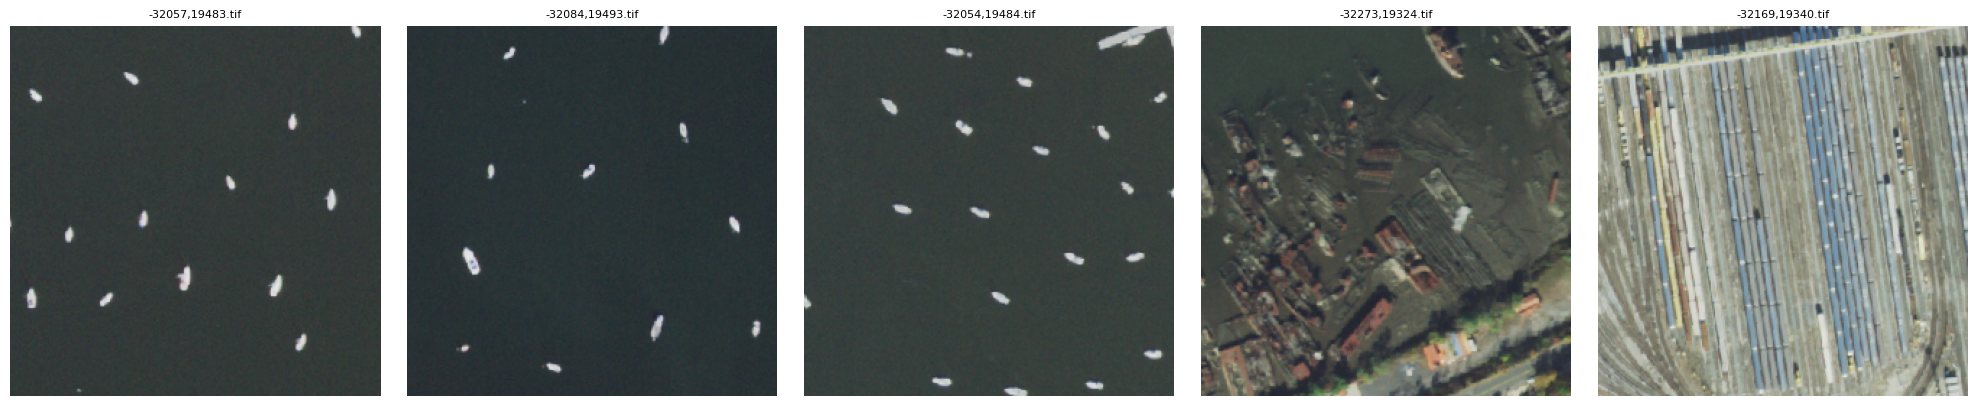

In [43]:
from google.cloud import storage
from PIL import Image
import io
import matplotlib.pyplot as plt

# initialize once
storage_client = storage.Client(project=PROJECT_NAME)
bucket = storage_client.bucket(BUCKET_NAME)

paths = df_res["tile_id"].tolist()

# make a subplot row
fig, axs = plt.subplots(1, len(paths), figsize=(4*len(paths), 4))
if len(paths) == 1:
    axs = [axs]

for ax, gcs_path in zip(axs, paths):
    # download into memory
    blob = bucket.blob(gcs_path)
    img_bytes = blob.download_as_bytes()

    # open with PIL
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # plot
    ax.imshow(img)
    ax.set_title(gcs_path.split("/")[-1], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Test: Local Search with FAISS

In [44]:
import numpy as np
from google.cloud import bigquery
import torch

import faiss


In [45]:
DATASET_ID = os.getenv("DATASET_ID", "naip_embeddings")
TABLE_ID = os.getenv("TABLE_ID", "naip_embeddings_256")


In [46]:
def query_embeddings_to_numpy(project_id, dataset_id, table_id, limit=None):
    """
    Query BigQuery table and convert embeddings to numpy array.

    Args:
        project_id: Your GCP project ID
        dataset_id: BigQuery dataset ID
        table_id: BigQuery table ID
        limit: Optional limit on number of rows (for testing)

    Returns:
        numpy array of shape (N, D) where N is number of rows, D is embedding dimension
    """
    # Initialize BigQuery client
    client = bigquery.Client(project=project_id)

    # Build query
    query = f"""
    SELECT
        tile_id,
        embedding,
        geometry,
        acquisition_time
    FROM `{project_id}.{dataset_id}.{table_id}`
    """

    if limit:
        query += f" LIMIT {limit}"

    # Execute query
    query_job = client.query(query)
    results = query_job.result()

    # Convert to list of rows
    rows = list(results)

    if not rows:
        return np.array([]), []

    # Extract embeddings and convert to numpy array
    embeddings = []
    metadata = []

    for row in rows:
        # The embedding field is a repeated FLOAT, so it comes as a list
        embedding = list(row.embedding)
        embeddings.append(embedding)

        # Store metadata if needed
        metadata.append({
            "tile_id": row.tile_id,
            "geometry": row.geometry,
            "acquisition_time": row.acquisition_time
        })

    # Convert to numpy array
    embeddings_array = np.array(embeddings)

    print(f"Embeddings shape: {embeddings_array.shape}")
    print(f"Number of rows (N): {embeddings_array.shape[0]}")
    print(f"Embedding dimension (D): {embeddings_array.shape[1]}")

    return embeddings_array, metadata


def query_embeddings_to_torch(project_id, dataset_id, table_id, limit=None, device='cpu'):
    """
    Query BigQuery table and convert embeddings directly to PyTorch tensor.

    Args:
        project_id: Your GCP project ID
        dataset_id: BigQuery dataset ID
        table_id: BigQuery table ID
        limit: Optional limit on number of rows
        device: PyTorch device ('cpu', 'cuda', etc.)

    Returns:
        PyTorch tensor of shape (N, D)
    """
    embeddings_array, metadata = query_embeddings_to_numpy(
        project_id, dataset_id, table_id, limit
    )

    # Convert to PyTorch tensor
    embeddings_tensor = torch.from_numpy(embeddings_array).float().to(device)

    return embeddings_tensor, metadata


In [47]:
# if you had saved the csv before you could run the cell below this
embeddings_torch, metadata = query_embeddings_to_torch(
    PROJECT_NAME, DATASET_ID, TABLE_ID, limit=None
)


Embeddings shape: (42650, 768)
Number of rows (N): 42650
Embedding dimension (D): 768


In [48]:
import ast
import pandas as pd

# if you had saved the csv before you could also do
df_saved = pd.read_csv("df_embeddings_naip.csv")

# Parse the string‑encoded lists into actual Python lists
df_saved["embedding_list"] = df_saved["embedding"].apply(ast.literal_eval)

# Stack them into a 2D NumPy array of shape (n_rows, embedding_dim) and convert to torch
embeddings_torch_2 =  torch.from_numpy(np.vstack(df_saved["embedding_list"].values)).float().to(device)
metadata_2 = df_saved[["tile_id", "geometry", "acquisition_time"]].to_dict(orient="records")


In [49]:
def setup_faiss_index(embeddings_torch, metadata):
    """
    Set up FAISS index with BigQuery embeddings and create mapping to image paths.

    Args:
        embeddings_torch: PyTorch tensor of shape (N, D) with L2-normalized embeddings
        metadata: List of metadata dictionaries from BigQuery

    Returns:
        index: FAISS index
        tile_to_metadata: Dictionary mapping index to metadata
    """
    # Ensure embeddings are numpy and float32 (FAISS requirement)
    embeddings_np = embeddings_torch.cpu().numpy().astype(np.float32)

    # Create FAISS index
    D = embeddings_np.shape[1]
    index = faiss.IndexFlatIP(D)  # Inner product for cosine similarity with normalized vectors
    index.add(embeddings_np)

    # Create mapping from index to metadata
    tile_to_metadata = {i: meta for i, meta in enumerate(metadata)}

    print(f"FAISS index created with {index.ntotal} vectors of dimension {D}")

    return index, tile_to_metadata


In [50]:
index, tile_to_metadata = setup_faiss_index(embeddings_torch, metadata)
# index, tile_to_metadata = setup_faiss_index(embeddings_torch_2, metadata_2)

FAISS index created with 42650 vectors of dimension 768


In [51]:
def search_with_faiss(query_vector, index, tile_to_metadata, k=5):
    """
    Search FAISS index and return results with image paths and metadata.

    Args:
        query_vector: Query embedding vector (numpy array)
        index: FAISS index
        tile_to_metadata: Mapping from index to metadata
        k: Number of results to return

    Returns:
        List of tuples (image_path, score, metadata)
    """
    # Ensure query vector is the right shape and type
    if query_vector.ndim == 1:
        query_vector = query_vector.reshape(1, -1)
    query_vector = query_vector.astype(np.float32)

    # Search
    scores, idxs = index.search(query_vector, k)

    results = []
    for j, idx in enumerate(idxs[0]):
        metadata = tile_to_metadata[idx]
        tile_id = metadata['tile_id']
        score = float(scores[0, j])

        results.append((tile_id, score, metadata))

    return results

def search_with_text_query(query_text, model, tokenizer, device, index, tile_to_metadata, k=5):
    """
    Search using text query (like your original function).

    Args:
        query_text: Text query string
        model: Your text encoder model
        tokenizer: Your tokenizer
        device: PyTorch device
        index: FAISS index
        tile_to_metadata: Mapping from index to metadata
        k: Number of results to return

    Returns:
        List of tuples (image_path, score, metadata)
    """
    # 1) text → vector
    tokens = tokenizer([query_text])[0].to(device)
    with torch.no_grad():
        qv = model.encode_text(tokens.unsqueeze(0), normalize=True).cpu().numpy()

    # 2) search
    return search_with_faiss(qv, index, tile_to_metadata, k)


In [52]:
# querys
# football field, airplanes, ships and boats, a single tree in an empty field, car in the road
# car under trees, cloud, letters in building, construction sites, islands, roundabouts
# basketball court, swimming pools, airport strips
results = search_with_text_query(
    "roundabouts", model, tokenizer, device,
    index, tile_to_metadata, k=8
)


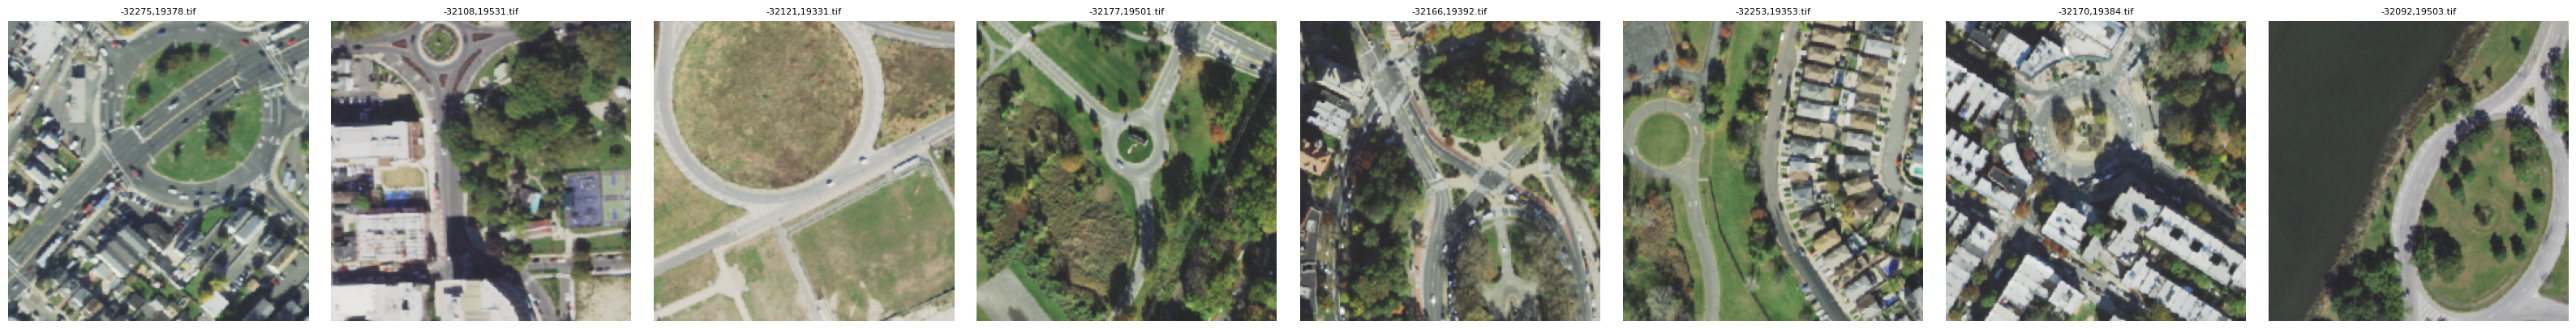

In [53]:
from google.cloud import storage
from PIL import Image
import io
import matplotlib.pyplot as plt

# initialize once
storage_client = storage.Client(project=PROJECT_NAME)
bucket = storage_client.bucket(BUCKET_NAME)

paths = [res[2]["tile_id"] for res in results]

# make a subplot row
fig, axs = plt.subplots(1, len(paths), figsize=(4*len(paths), 4))
if len(paths) == 1:
    axs = [axs]

for ax, gcs_path in zip(axs, paths):
    # download into memory
    blob = bucket.blob(gcs_path)
    img_bytes = blob.download_as_bytes()

    # open with PIL
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # plot
    ax.imshow(img)
    ax.set_title(gcs_path.split("/")[-1], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Test: BigQuery Vector Search

In [54]:
def encode_text_query(query_text, model, tokenizer, device):
    """
    Encode text query to embedding vector using the model.
    """
    tokens = tokenizer([query_text])[0].to(device)
    with torch.no_grad():
        query_vector = model.encode_text(tokens.unsqueeze(0), normalize=True).cpu().numpy()

    print(f"Query: '{query_text}'")
    print(f"Query vector shape: {query_vector.shape}")
    return query_vector


In [55]:
def vector_search_bq(query_vector, project_id, dataset_id, table_id, top_k=20, distance_threshold=0.1, fraction_lists_to_search=0.01):
    """
    Perform vector search in BigQuery using VECTOR_SEARCH.

    Args:
        query_vector: numpy array of the query embedding (shape: 1 x D)
        project_id: GCP project ID
        dataset_id: BigQuery dataset ID
        table_id: BigQuery table ID
        top_k: Number of top results to return
        distance_threshold: Maximum distance threshold for filtering
        fraction_lists_to_search: Fraction of IVF lists to search (trade-off between speed and accuracy)

    Returns:
        Query results from BigQuery
    """
    client = bigquery.Client(project=project_id)

    # Convert query vector to BigQuery ARRAY format
    # Flatten if it's 2D and convert to list
    if query_vector.ndim == 2:
        query_vector = query_vector.flatten()

    query_vector_list = query_vector.tolist()
    print(f"Query vector (length {len(query_vector_list)}): {query_vector_list}")

    # Build the query
    query = f"""
    WITH query_embedding AS (
      SELECT {query_vector_list} AS embedding
    )

    SELECT
      base.tile_id,
      base.embedding,
      base.geometry,
      base.acquisition_time,
      distance
    FROM
      VECTOR_SEARCH(
        TABLE `{project_id}.{dataset_id}.{table_id}`,
        'embedding',
        TABLE query_embedding,
        TOP_K         => {top_k},
        DISTANCE_TYPE => 'COSINE',
        OPTIONS       => '{{"fraction_lists_to_search": {fraction_lists_to_search}}}'
      )
    WHERE distance > 0
      AND distance < {distance_threshold}
    ORDER BY distance
    LIMIT {top_k};
    """

    print("Executing BigQuery vector search...")
    query_job = client.query(query)
    results = query_job.result()

    return list(results)


In [57]:
def text_search_bq(query_text, model, tokenizer, device, project_id, dataset_id, table_id,
                   top_k=20, distance_threshold=0.1, fraction_lists_to_search=0.01):
    """
    Complete pipeline: text query -> embedding -> BigQuery vector search.

    Args:
        query_text: Text query string
        model: Your text encoder model
        tokenizer: Your tokenizer
        device: PyTorch device
        project_id: GCP project ID
        dataset_id: BigQuery dataset ID
        table_id: BigQuery table ID
        top_k: Number of top results to return
        distance_threshold: Maximum distance threshold
        fraction_lists_to_search: Fraction of IVF lists to search

    Returns:
        List of BigQuery result rows
    """
    # 1. Encode text to vector
    query_vector = encode_text_query(query_text, model, tokenizer, device)

    # 2. Perform vector search
    results = vector_search_bq(
        query_vector, project_id, dataset_id, table_id,
        top_k, distance_threshold, fraction_lists_to_search
    )

    return results


In [56]:
DATASET_ID = os.getenv("DATASET_ID", "naip_embeddings")
TABLE_ID = os.getenv("TABLE_ID", "naip_embeddings_256")


In [58]:
# Search parameters
QUERY_TEXT = "airplanes"
TOP_K = 8
DISTANCE_THRESHOLD = 0.8
FRACTION_LISTS_TO_SEARCH = 0.001


In [59]:
results = text_search_bq(
    QUERY_TEXT, model, tokenizer, device,
    PROJECT_NAME, DATASET_ID, TABLE_ID,
    top_k=TOP_K,
    distance_threshold=DISTANCE_THRESHOLD,
    fraction_lists_to_search=FRACTION_LISTS_TO_SEARCH
)


Query: 'airplanes'
Query vector shape: (1, 768)
Query vector (length 768): [-0.010067428462207317, -0.008547421544790268, 0.03719419613480568, -0.0036109646316617727, -0.012976539321243763, 0.020647766068577766, 0.03244375064969063, 0.029030878096818924, -0.010730098001658916, 0.02206972986459732, -0.013010104186832905, -0.018276290968060493, 0.030697550624608994, -0.006988396868109703, 0.034792061895132065, -0.006658563390374184, 0.01515840645879507, 0.020741237327456474, -0.03075285442173481, 0.00022513563453685492, -0.004356044810265303, -0.011090867221355438, -0.033898063004016876, 0.025081053376197815, 9.092876280192286e-05, 0.030345745384693146, -0.013478499837219715, -0.007030535023659468, -0.0403328463435173, -0.02598491869866848, 0.006221993360668421, 0.01728486455976963, -0.02370661124587059, 0.001670809811912477, 0.009125018492341042, -0.00010581076639937237, -0.005102949216961861, -0.018969275057315826, 0.01661556586623192, -0.009164360351860523, -0.018402261659502983, 0.03

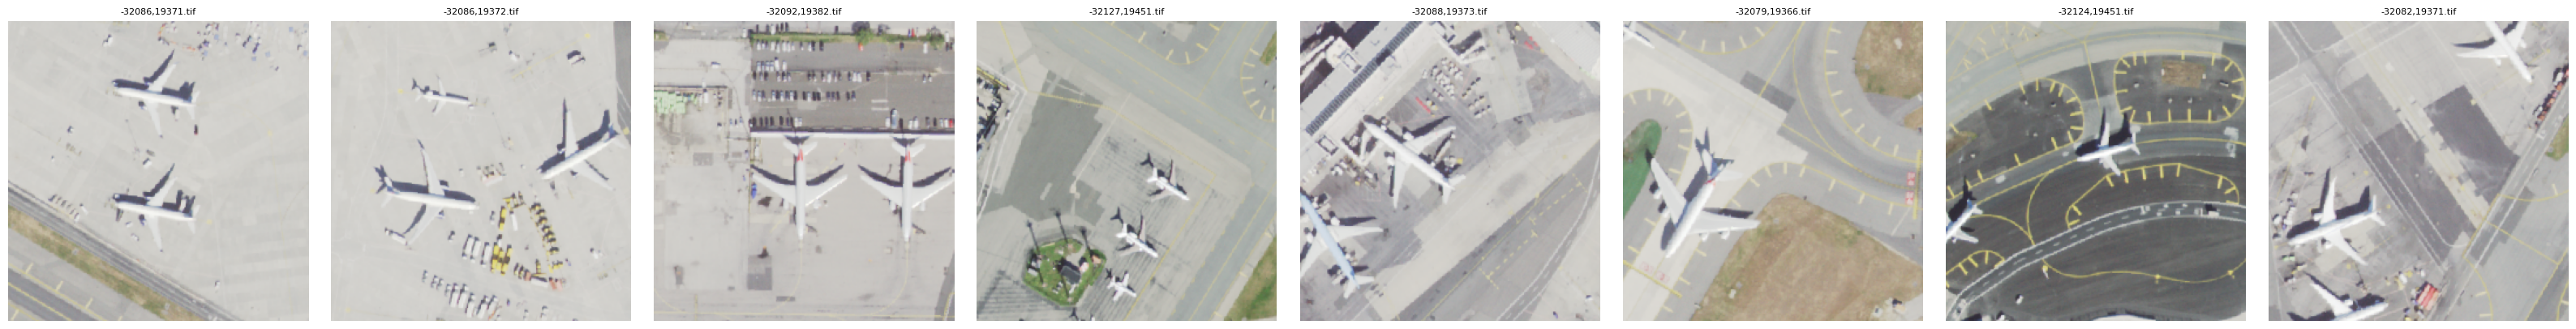

In [60]:
from google.cloud import storage
from PIL import Image
import io
import matplotlib.pyplot as plt

# initialize once
storage_client = storage.Client(project=PROJECT_NAME)
bucket = storage_client.bucket(BUCKET_NAME)

paths = [res[0] for res in results]

# make a subplot row
fig, axs = plt.subplots(1, len(paths), figsize=(4*len(paths), 4))
if len(paths) == 1:
    axs = [axs]

for ax, gcs_path in zip(axs, paths):
    # download into memory
    blob = bucket.blob(gcs_path)
    img_bytes = blob.download_as_bytes()

    # open with PIL
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # plot
    ax.imshow(img)
    ax.set_title(gcs_path.split("/")[-1], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()
